<a href="https://colab.research.google.com/github/ggalarza1/finance/blob/master/SP500_interactive_dashboard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Get S&P 500 Tickers

I will retrieve the S&P 500 ticker symbols from Wikipedia using the `pandas` library.

In [4]:
import pandas as pd
import requests
from bs4 import BeautifulSoup

# URL of the Wikipedia page listing S&P 500 companies
url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'

# Add a User-Agent header to mimic a web browser
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
}

# Fetch the HTML content using requests
response = requests.get(url, headers=headers)
response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)

# Parse the HTML content using BeautifulSoup
soup = BeautifulSoup(response.text, 'html.parser')

# Find the table containing the S&P 500 companies
# Wikipedia tables often have specific classes or IDs. The S&P 500 table is usually the first 'wikitable'
tables = soup.find_all('table', {'class': 'wikitable'})

# Assuming the S&P 500 companies table is the first wikitable found
if tables:
    sp500_html_table = tables[0]
    # Convert the HTML table to a pandas DataFrame
    sp500_table = pd.read_html(str(sp500_html_table))[0]
else:
    raise ValueError("Could not find the S&P 500 table on the Wikipedia page.")

# Display the first few rows of the table to inspect its structure
display(sp500_table.head())

/tmp/ipykernel_903/3434780410.py:28: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  sp500_table = pd.read_html(str(sp500_html_table))[0]


,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989


From the table, the 'Symbol' column contains the S&P 500 tickers.

In [5]:
# Extract the 'Symbol' column as the list of tickers
sp500_tickers = sp500_table['Symbol'].tolist()

print(f"Number of S&P 500 tickers found: {len(sp500_tickers)}")
print("First 10 S&P 500 tickers:")
print(sp500_tickers[:10])

Number of S&P 500 tickers found: 503
First 10 S&P 500 tickers:
['MMM', 'AOS', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'AES', 'AFL', 'A']


## Retrieve Historical Stock Data

Now that we have the list of S&P 500 tickers, we can retrieve historical stock data for them. We will use the `yfinance` library for this purpose.

First, we need to install `yfinance`.

In [6]:
!pip install yfinance

Next, we'll download historical data for a *subset* of these tickers to avoid making too many requests and overwhelming the system. We'll fetch data for the last year.

In [7]:
import yfinance as yf

# Select a subset of tickers for demonstration purposes
# For example, the first 10 tickers
sample_tickers = sp500_tickers[:10]

# Define the period for historical data (e.g., 1 year)
period = '1y'

# Download historical data for the sample tickers
data = yf.download(sample_tickers, period=period)

# Display the first few rows of the downloaded data
print("Historical Data for Sample Tickers (first 5 rows):")
display(data.head())

/tmp/ipykernel_903/2403136430.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(sample_tickers, period=period)
[*********************100%***********************]  10 of 10 completed


Historical Data for Sample Tickers (first 5 rows):


Price            Close                                                  \
Ticker               A        ABBV         ABT         ACN        ADBE   
Date                                                                     
2025-06-16  118.051018  184.838303  131.327194  310.135681  401.730011   
2025-06-17  115.144859  179.628052  129.631866  307.866394  382.679993   
2025-06-18  114.579506  179.637741  129.759247  302.291779  378.040009   
2025-06-20  114.619186  179.453735  130.327637  281.562134  376.920013   
2025-06-23  115.184540  177.962311  130.592224  291.063629  380.119995   

Price                                                                 ...  \
Ticker            AES         AFL         AMD        AOS         MMM  ...   
Date                                                                  ...   
2025-06-16  10.899637  100.574509  126.389999  62.994377  142.406174  ...   
2025-06-17  10.015111   99.957649  127.099998  61.926842  139.598694  ...   
2025-06-18  10.005601  100.486374  126.790001  61.779934  139.893173  ...   
2025-06-20   9.900978  101.142380  128.240005  61.446941  141.385254  ...   
2025-06-23   9.653692  102.650208  129.580002  62.818085  144.889725  ...   

Price          Volume                                               \
Ticker              A      ABBV         ABT         ACN       ADBE   
Date                                                                 
2025-06-16  1402800.0   4203900   5084100.0   2930000.0  6798300.0   
2025-06-17  1577100.0   4733900   5010800.0   2533800.0  6866300.0   
2025-06-18  1560300.0   3573200   4950400.0   4593100.0  4808900.0   
2025-06-20  3043900.0  12158100  11338200.0  11697400.0  8126900.0   
2025-06-23  1448400.0   5157900   4887200.0   5454900.0  3841800.0   

Price                                                                 
Ticker             AES        AFL          AMD        AOS        MMM  
Date                                                                  
2025-06-16  11948600.0  2160800.0  100968500.0  1551800.0  1681300.0  
2025-06-17  28143100.0  2056900.0   86623900.0  1422100.0  1739900.0  
2025-06-18  18232800.0  2127300.0   49627100.0  1198800.0  2629100.0  
2025-06-20  18140300.0  6258900.0   79931000.0  2773600.0  5566700.0  
2025-06-23  13611700.0  2156600.0   65152900.0  1386600.0  2904700.0  

[5 rows x 50 columns]

## Visualize Historical Stock Data

Let's plot the 'Close' prices for the `sample_tickers` to visualize their trends over the last year. This will give us a preliminary view of their performance.

<Figure size 1400x700 with 0 Axes>

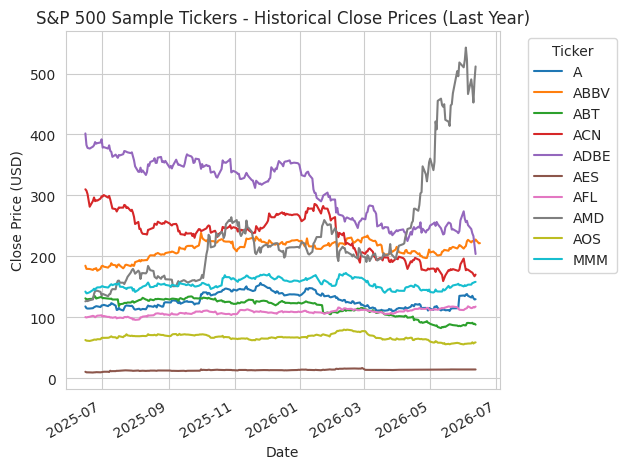

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for the plots
sns.set_style('whitegrid')

# Extract 'Close' prices
close_prices = data['Close']

# Plot the 'Close' prices
plt.figure(figsize=(14, 7))
close_prices.plot()
plt.title('S&P 500 Sample Tickers - Historical Close Prices (Last Year)')
plt.xlabel('Date')
plt.ylabel('Close Price (USD)')
plt.legend(title='Ticker', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

## Create an Interactive Dashboard with Plotly

To create an interactive dashboard, we'll use the `plotly` library, which allows for dynamic and interactive visualizations directly within the notebook or as standalone HTML files.

First, let's install `plotly`.

In [9]:
!pip install plotly

Now, let's create an interactive line chart of the 'Close' prices using `plotly.express`. This will allow you to zoom, pan, and hover over the data points to see specific values.

In [10]:
import plotly.express as px

# Reset the index to make 'Date' a regular column for Plotly
plot_data = close_prices.reset_index()

# Melt the DataFrame to long format for easier plotting with Plotly Express
# This stacks the ticker columns into two columns: 'Ticker' and 'Close Price'
plot_data_melted = plot_data.melt(id_vars=['Date'], var_name='Ticker', value_name='Close Price')

# Create an interactive line chart using Plotly Express
fig = px.line(plot_data_melted,
              x='Date',
              y='Close Price',
              color='Ticker',
              title='Interactive S&P 500 Sample Tickers - Historical Close Prices (Last Year)')

# Update layout for better readability
fig.update_layout(
    xaxis_title='Date',
    yaxis_title='Close Price (USD)',
    hovermode='x unified'
)

# Show the interactive plot
fig.show()

## Calculate and Visualize Daily Returns

Next, let's calculate the daily returns for our sample tickers. Daily returns provide insight into the day-to-day percentage change in stock prices. We'll then visualize these returns interactively using Plotly.

In [11]:
# Calculate daily returns from the 'Close' prices
daily_returns = close_prices.pct_change()

print("Daily Returns for Sample Tickers (first 5 rows):")
display(daily_returns.head())

Daily Returns for Sample Tickers (first 5 rows):


/tmp/ipykernel_903/1459081303.py:2: FutureWarning:

The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.



Ticker,A,ABBV,ABT,ACN,ADBE,AES,AFL,AMD,AOS,MMM
Date,,,,,,,,,,
2025-06-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-06-17,-0.024618,-0.028188,-0.012909,-0.007317,-0.047420,-0.081152,-0.006133,0.005618,-0.016947,-0.019715
2025-06-18,-0.004910,0.000054,0.000983,-0.018107,-0.012125,-0.000950,0.005289,-0.002439,-0.002372,0.002109
2025-06-20,0.000346,-0.001024,0.004380,-0.068575,-0.002963,-0.010456,0.006528,0.011436,-0.005390,0.010666
2025-06-23,0.004932,-0.008311,0.002030,0.033746,0.008490,-0.024976,0.014908,0.010449,0.022314,0.024787


Now, let's visualize these daily returns with an interactive Plotly line chart. This will allow for easy inspection of volatility and performance on specific days.

In [12]:
import plotly.express as px

# Reset the index for Plotly and melt the DataFrame
plot_returns = daily_returns.reset_index()
plot_returns_melted = plot_returns.melt(id_vars=['Date'], var_name='Ticker', value_name='Daily Return')

# Create an interactive line chart for daily returns
fig_returns = px.line(plot_returns_melted,
                      x='Date',
                      y='Daily Return',
                      color='Ticker',
                      title='Interactive S&P 500 Sample Tickers - Daily Returns (Last Year)',
                      labels={'Daily Return': 'Daily Return (%)'})

# Update layout for better readability
fig_returns.update_layout(
    xaxis_title='Date',
    yaxis_title='Daily Return',
    hovermode='x unified'
)

# Add a horizontal line at y=0 for reference
fig_returns.add_hline(y=0, line_dash='dash', line_color='grey')

# Show the interactive plot
fig_returns.show()

## Calculate and Visualize Cumulative Returns

Cumulative returns show the total percentage change in value over time. This can be very insightful for understanding the overall performance of each ticker in our sample. We'll calculate these and then visualize them with another interactive Plotly chart.

In [13]:
# Calculate cumulative returns
# We'll use (1 + daily_returns).cumprod() - 1 to get the cumulative percentage change
cumulative_returns = (1 + daily_returns).cumprod() - 1

print("Cumulative Returns for Sample Tickers (first 5 rows):")
display(cumulative_returns.head())

Cumulative Returns for Sample Tickers (first 5 rows):


Ticker,A,ABBV,ABT,ACN,ADBE,AES,AFL,AMD,AOS,MMM
Date,,,,,,,,,,
2025-06-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-06-17,-0.024618,-0.028188,-0.012909,-0.007317,-0.047420,-0.081152,-0.006133,0.005618,-0.016947,-0.019715
2025-06-18,-0.029407,-0.028136,-0.011939,-0.025292,-0.058970,-0.082024,-0.000876,0.003165,-0.019279,-0.017647
2025-06-20,-0.029071,-0.029131,-0.007611,-0.092132,-0.061758,-0.091623,0.005646,0.014637,-0.024565,-0.007169
2025-06-23,-0.024282,-0.037200,-0.005596,-0.061496,-0.053792,-0.114311,0.020638,0.025239,-0.002799,0.017440


Now, let's create an interactive Plotly line chart for the cumulative returns. This will visually represent the growth (or decline) of an initial investment in each of these stocks.

In [14]:
import plotly.express as px

# Reset the index for Plotly and melt the DataFrame
plot_cumulative_returns = cumulative_returns.reset_index()
plot_cumulative_returns_melted = plot_cumulative_returns.melt(id_vars=['Date'], var_name='Ticker', value_name='Cumulative Return')

# Create an interactive line chart for cumulative returns
fig_cumulative_returns = px.line(plot_cumulative_returns_melted,
                                 x='Date',
                                 y='Cumulative Return',
                                 color='Ticker',
                                 title='Interactive S&P 500 Sample Tickers - Cumulative Returns (Last Year)',
                                 labels={'Cumulative Return': 'Cumulative Return (%)'})

# Update layout for better readability
fig_cumulative_returns.update_layout(
    xaxis_title='Date',
    yaxis_title='Cumulative Return',
    hovermode='x unified'
)

# Add a horizontal line at y=0 for reference
fig_cumulative_returns.add_hline(y=0, line_dash='dash', line_color='grey')

# Show the interactive plot
fig_cumulative_returns.show()